# **Monte Carlo ES for Blackjack**


### **Assignment 4 - Reinforcement Learning - MSc. Computer Science, AUEB [2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

Episode 250,000/5,000,000 | mean(V)=0.0838
Episode 500,000/5,000,000 | mean(V)=0.0836
Episode 750,000/5,000,000 | mean(V)=0.0850
Episode 1,000,000/5,000,000 | mean(V)=0.0850
Episode 1,250,000/5,000,000 | mean(V)=0.0841
Episode 1,500,000/5,000,000 | mean(V)=0.0830
Episode 1,750,000/5,000,000 | mean(V)=0.0832
Episode 2,000,000/5,000,000 | mean(V)=0.0837
Episode 2,250,000/5,000,000 | mean(V)=0.0833
Episode 2,500,000/5,000,000 | mean(V)=0.0835
Episode 2,750,000/5,000,000 | mean(V)=0.0834
Episode 3,000,000/5,000,000 | mean(V)=0.0834
Episode 3,250,000/5,000,000 | mean(V)=0.0835
Episode 3,500,000/5,000,000 | mean(V)=0.0835
Episode 3,750,000/5,000,000 | mean(V)=0.0835
Episode 4,000,000/5,000,000 | mean(V)=0.0838
Episode 4,250,000/5,000,000 | mean(V)=0.0838
Episode 4,500,000/5,000,000 | mean(V)=0.0838
Episode 4,750,000/5,000,000 | mean(V)=0.0838
Episode 5,000,000/5,000,000 | mean(V)=0.0839


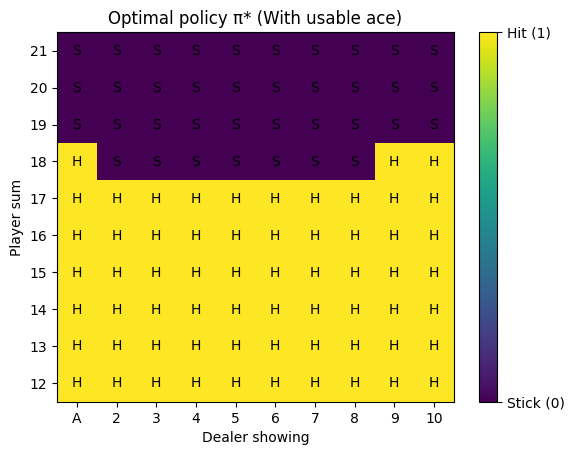

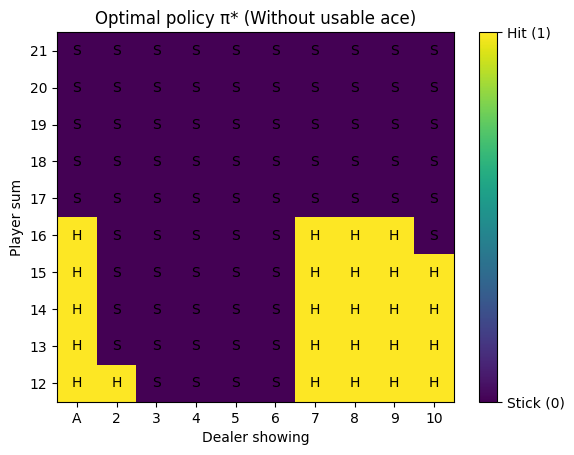

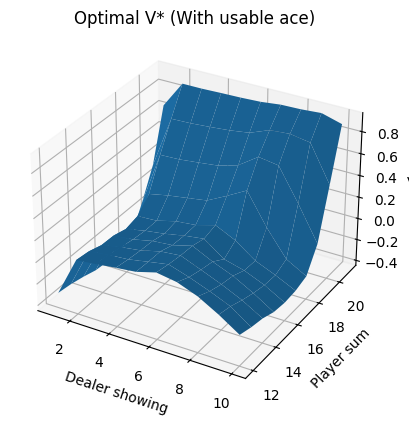

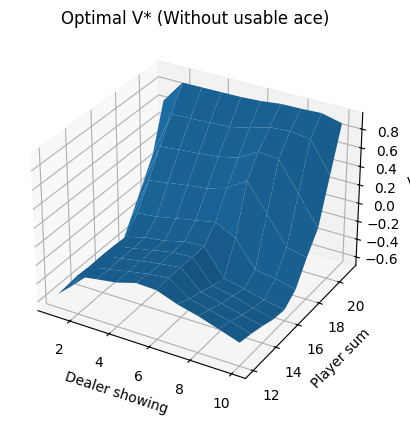

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Helpers: cards / hand values
# -----------------------------
def generate_card(rng: np.random.Generator) -> int:
    """Ace=1, 2..9, 10 for 10/J/Q/K with prob 4/13."""
    probs = np.array([1] * 9 + [4], dtype=float) / 13.0
    return int(rng.choice(np.arange(1, 11), p=probs))


def hand_value(hand) -> int:
    """Blackjack value: count one Ace as 11 if it doesn't bust."""
    s = sum(hand)
    if 1 in hand and s + 10 <= 21:
        return s + 10
    return s


def usable_ace(hand) -> bool:
    """True if there's an Ace being used as 11."""
    s = sum(hand)
    return (1 in hand) and (s + 10 <= 21)


def is_bust(hand) -> bool:
    return hand_value(hand) > 21


# -----------------------------
# Player / Dealer
# -----------------------------
class Player:
    def __init__(self, hand, dealer_show):
        self.hand = list(hand)
        self.dealer_show = dealer_show

    def add_card(self, card):
        self.hand.append(card)

    def value(self):
        return hand_value(self.hand)

    def bust(self):
        return is_bust(self.hand)

    def state(self):
        # Sutton & Barto state = (player_sum 12..21, dealer_show 1..10, usable_ace 0/1)
        return (self.value(), self.dealer_show, int(usable_ace(self.hand)))


class Dealer:
    def __init__(self, hand):
        self.hand = list(hand)

    def add_card(self, card):
        self.hand.append(card)

    def value(self):
        return hand_value(self.hand)

    def bust(self):
        return is_bust(self.hand)

    def should_hit(self):
        # dealer hits until reaching 17+
        return self.value() < 17


# -----------------------------
# Exploring starts: build hands consistent with abstract state
# -----------------------------
def make_player_hand_from_state(player_sum: int, use_ace: int) -> list[int]:
    """
    Construct a real hand consistent with (player_sum, usable_ace).
    player_sum is in 12..21.
    """
    if use_ace == 1:
        # [Ace, x] with 11 + x = player_sum => x = player_sum - 11 in 1..10
        x = player_sum - 11
        x = int(np.clip(x, 1, 10))
        return [1, x]

    # no usable ace: choose two cards a,b in 1..10 that sum to player_sum and do NOT form usable ace
    for a in range(10, 1, -1):
        b = player_sum - a
        if 1 <= b <= 10:
            hand = [a, int(b)]
            if (not usable_ace(hand)) and (hand_value(hand) == player_sum):
                return hand

    # fallback
    return [10, player_sum - 10]


def make_dealer_hand_from_show(dealer_show: int, rng: np.random.Generator) -> list[int]:
    """Dealer showing is fixed; hidden card random."""
    return [dealer_show, generate_card(rng)]


# -----------------------------
# Epsilon-greedy policy on Q
# -----------------------------
def epsilon_greedy_action(Q, s, epsilon, rng):
    """Actions: 0=stick, 1=hit"""
    if rng.random() < epsilon:
        return int(rng.integers(0, 2))

    # greedy w/ tie-break
    q0, q1 = Q[s][0], Q[s][1]
    if np.isclose(q0, q1):
        return int(rng.integers(0, 2))
    return int(q1 > q0)


# -----------------------------
# One MC-ES episode
# -----------------------------
def mc_es_episode(Q, epsilon, rng):
    """
    Exploring start:
      - sample state uniformly: player_sum in 12..21, dealer_show in 1..10, usable_ace in {0,1}
      - sample first action uniformly
    Then follow epsilon-greedy thereafter.
    Returns: visited (state, action) pairs (first-visit set handled outside) and terminal reward G.
    """
    player_sum = int(rng.integers(12, 22))        # 12..21
    dealer_show = int(rng.integers(1, 11))        # 1..10 (1 = Ace)
    use_ace = int(rng.integers(0, 2))             # 0/1
    first_action = int(rng.integers(0, 2))        # 0 stick, 1 hit

    player_hand = make_player_hand_from_state(player_sum, use_ace)
    dealer_hand = make_dealer_hand_from_show(dealer_show, rng)

    player = Player(player_hand, dealer_show)
    dealer = Dealer(dealer_hand)

    visited = []
    a = first_action

    while True:
        s = player.state()

        # decision states only defined for 12..21
        # (we still guard just in case)
        if s[0] < 12:
            a = 1
        elif s[0] > 21:
            break

        visited.append((s, a))

        if a == 0:  # stick
            break

        # hit
        player.add_card(generate_card(rng))

        if player.bust():
            break

        # auto-hit below 12 (not part of state space)
        while player.value() < 12:
            player.add_card(generate_card(rng))
            if player.bust():
                break

        if player.bust():
            break

        # follow epsilon-greedy after first step
        s = player.state()
        a = epsilon_greedy_action(Q, s, epsilon, rng)

    # terminal reward
    if player.bust():
        G = -1
        return visited, G

    # dealer plays out
    while (not dealer.bust()) and dealer.should_hit():
        dealer.add_card(generate_card(rng))

    if dealer.bust():
        G = +1
    else:
        pv, dv = player.value(), dealer.value()
        G = (pv > dv) - (pv < dv)

    return visited, G


# -----------------------------
# Monte Carlo ES Control
# -----------------------------
def monte_carlo_es(num_episodes=5_000_000, epsilon=0.1, seed=1, print_every=250_000):
    """
    Returns:
      Q[(player_sum, dealer_show, usable_ace)][action] -> float
      policy[(player_sum, dealer_show, usable_ace)] -> 0/1
      V[(player_sum, dealer_show, usable_ace)] -> float
    """
    rng = np.random.default_rng(seed)

    # initialize dictionaries over state-action space
    Q = {}
    N = {}
    policy = {}

    for ps in range(12, 22):
        for ds in range(1, 11):
            for ua in (0, 1):
                s = (ps, ds, ua)
                Q[s] = np.array([0.0, 0.0])   # [stick, hit]
                N[s] = np.array([0, 0], dtype=np.int64)

                # common initial policy from book example: stick only on 20 or 21
                policy[s] = 0 if ps in (20, 21) else 1

    for ep in range(1, num_episodes + 1):
        visited, G = mc_es_episode(Q, epsilon, rng)

        # first-visit MC update
        seen = set()
        for (s, a) in visited:
            if (s, a) in seen:
                continue
            seen.add((s, a))

            ps, ds, ua = s
            if not (12 <= ps <= 21):
                continue

            N[s][a] += 1
            Q[s][a] += (G - Q[s][a]) / N[s][a]

            # greedy improvement
            policy[s] = int(Q[s][1] > Q[s][0])

        if print_every and ep % print_every == 0:
            # quick progress indicator
            vals = [max(Q[s][0], Q[s][1]) for s in Q]
            print(f"Episode {ep:,}/{num_episodes:,} | mean(V)={np.mean(vals):.4f}")

    V = {s: float(np.max(Q[s])) for s in Q}
    return Q, policy, V


# -----------------------------
# Plotting
# -----------------------------
def plot_policy(policy, title, usable_ace_flag):
    """
    Heatmap of hit/stick with H/S overlay.
    usable_ace_flag: 0 or 1
    """
    data = np.zeros((10, 10), dtype=int)  # rows ps=12..21, cols ds=1..10

    for i, ps in enumerate(range(12, 22)):
        for j, ds in enumerate(range(1, 11)):
            s = (ps, ds, usable_ace_flag)
            data[i, j] = policy[s]  # 0 stick, 1 hit

    fig, ax = plt.subplots()
    ax.set_title(title)
    im = ax.imshow(data, origin="lower", aspect="auto", vmin=0, vmax=1)

    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10))
    ax.set_xticklabels(["A","2","3","4","5","6","7","8","9","10"])
    ax.set_yticks(range(10))
    ax.set_yticklabels([str(x) for x in range(12, 22)])

    for i in range(10):
        for j in range(10):
            ax.text(j, i, "H" if data[i, j] == 1 else "S", ha="center", va="center")

    cbar = fig.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.ax.set_yticklabels(["Stick (0)", "Hit (1)"])
    plt.show()


def plot_value_surface(V, title, usable_ace_flag):
    """3D surface plot of V*(player_sum, dealer_show) for fixed usable_ace."""
    X, Y = np.meshgrid(np.arange(1, 11), np.arange(12, 22))
    Z = np.zeros((10, 10), dtype=float)

    for i, ps in enumerate(range(12, 22)):
        for j, ds in enumerate(range(1, 11)):
            Z[i, j] = V[(ps, ds, usable_ace_flag)]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_zlabel("V*")
    ax.plot_surface(X, Y, Z)
    plt.show()


if __name__ == "__main__":
    EPISODES = 5_000_000
    EPSILON = 0.1
    SEED = 1

    Q, policy, V = monte_carlo_es(
        num_episodes=EPISODES,
        epsilon=EPSILON,
        seed=SEED,
        print_every=250_000
    )

    plot_policy(policy, "Optimal policy π* (With usable ace)", usable_ace_flag=1)
    plot_policy(policy, "Optimal policy π* (Without usable ace)", usable_ace_flag=0)

    plot_value_surface(V, "Optimal V* (With usable ace)", usable_ace_flag=1)
    plot_value_surface(V, "Optimal V* (Without usable ace)", usable_ace_flag=0)
